
## comparing the 3 countries and storing result

C:\Users\hp\AppData\Local\Temp\ipykernel_1960\3339750194.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=weighted_df, x='Country', y='Weighted_Wins', palette='magma')


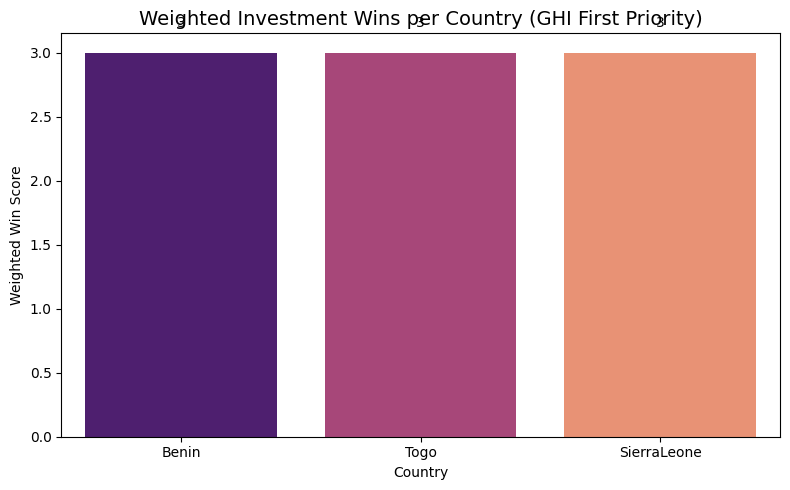

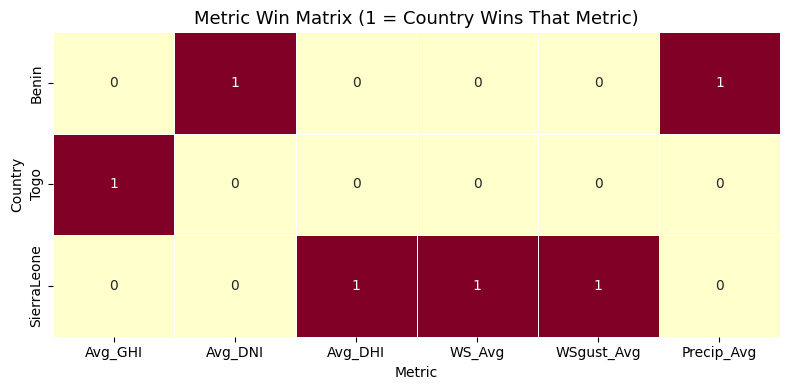


✅ Based on weighted metrics (GHI prioritized), the best country to invest in is: **Benin**

📁 Weighted summary saved to '../final/weighted_metric_summary.csv'


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# === Load your final data ===
file_path = Path("../final/final2.csv")
summary_df = pd.read_csv(file_path)

# === Define metrics and their importance ===
# Higher weight = more important for investment
metrics = {
    'Avg_GHI': {'mode': 'max', 'weight': 3},   # Most important
    'Avg_DNI': {'mode': 'max', 'weight': 2},
    'Avg_DHI': {'mode': 'max', 'weight': 1},
    'WS_Avg': {'mode': 'min', 'weight': 1},
    'WSgust_Avg': {'mode': 'min', 'weight': 1},
    'Precip_Avg': {'mode': 'min', 'weight': 1}
}

# === Helper function to find winners ===
def find_winners(df, metrics):
    winners = {}
    for metric, rule in metrics.items():
        if metric not in df.columns:
            continue
        if rule['mode'] == 'max':
            best_val = df[metric].max()
            winners[metric] = df.loc[df[metric] == best_val, 'Country'].tolist()
        elif rule['mode'] == 'min':
            best_val = df[metric].min()
            winners[metric] = df.loc[df[metric] == best_val, 'Country'].tolist()
        elif rule['mode'] == 'closest':
            target = rule.get('target', 30)
            dist = (df[metric] - target).abs()
            best_val = dist.min()
            winners[metric] = df.loc[dist == best_val, 'Country'].tolist()
    return winners

# === Find winners for each metric ===
winners = find_winners(summary_df, metrics)

# === Weighted win counting ===
weighted_wins = {c: 0 for c in summary_df['Country']}
for metric, countries in winners.items():
    for c in countries:
        weighted_wins[c] += metrics[metric]['weight']

# === Create DataFrame for plotting ===
weighted_df = pd.DataFrame({
    'Country': list(weighted_wins.keys()),
    'Weighted_Wins': list(weighted_wins.values())
}).sort_values(by='Weighted_Wins', ascending=False)

# === 1️⃣ Bar Chart: Weighted Wins (Investment Score by Importance) ===
plt.figure(figsize=(8, 5))
sns.barplot(data=weighted_df, x='Country', y='Weighted_Wins', palette='magma')
plt.title("Weighted Investment Wins per Country (GHI First Priority)", fontsize=14)
plt.xlabel("Country")
plt.ylabel("Weighted Win Score")
for index, row in weighted_df.iterrows():
    plt.text(index, row['Weighted_Wins'] + 0.2, int(row['Weighted_Wins']), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

# === 2️⃣ Heatmap: Which Country Wins Which Metric ===
heat_data = pd.DataFrame(0, index=summary_df['Country'], columns=metrics.keys())
for metric, countries in winners.items():
    for c in countries:
        heat_data.loc[c, metric] = 1

plt.figure(figsize=(8, 4))
sns.heatmap(heat_data, annot=True, cmap='YlOrRd', cbar=False, linewidths=0.5)
plt.title("Metric Win Matrix (1 = Country Wins That Metric)", fontsize=13)
plt.xlabel("Metric")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

# === Final Recommendation ===
best_country = weighted_df.loc[weighted_df['Weighted_Wins'].idxmax(), 'Country']
print(f"\n✅ Based on weighted metrics (GHI prioritized), the best country to invest in is: **{best_country}**")

# Save summary for record
weighted_df.to_csv("../final/weighted_metric_summary.csv", index=False)
print("\n📁 Weighted summary saved to '../final/weighted_metric_summary.csv'")
